# Steps specific template

This is a template for analysing, cleaning, and extracting features for step count data collected by a phone, watch, or both. It is recommended to first read the general template to understand the pipeline used here. In addition to the dataset specifications set out in the general template, there should be a measurement column which is steps data (either absolute steps or cumulative steps). There may also be a device column that records whether each datapoint has been provided by a watch or phone. This pipeline is suitable for steps data with a range of sampling frequencies, such as daily, minute based, or event based.

If your data files contain a mix of both phone and watch data, they will only
need to be filtered if the data from different devices overlap. The functions
here have been designed to deal with data that comes in blocks from one device
at a time (for example, sensorkit pedometer data has previously been found to be
in this format). If the data does overlap you will need two copies of this
template for each device and to use the `filter_dict` optional variable in all
the functions.

## Data analysis

 First we do all imports necessary for this analysis and get `files_list`, a list of the file paths:

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(
    0, str(Path().resolve().parent / "src")
)  # Set the path to the src folder so that we can import the functions from there

import additional_funcs
import all_field_summaries
import calculate_durations
import feature_extraction
import helper_funcs
import timestamps_check

base_dir = Path.cwd().parent  # go up one level from where you're running
folder_path = base_dir / "example_data"
folder_path_str = str(folder_path) + "/"

# Set input variables
Folder_structure = 1  # This should be either 1 or 2 (see above)
csv_name = "active_apple_healthkit_steps"  # The standard name for the csv that contains this data
site_list = ["test"]  # The names of the subfolders for each site
input_folder = folder_path_str  # The folder that contains all the site subfolders

# Get a list of the paths to each file to be included in this analysis
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure, site_list
)

5 files found


### Investigate Frequency

Before examining the distribution of values we need to know the sampling
frequency to provide context to number of steps per datapoint. Therefore, for
steps data, we first run the `investigate_frequency` function.

If you wish to filter any columns, such as the device column, set the
`filter_dict` variable to `filter_dictionary` and edit the `filter_dictionary`
below.

In [2]:
# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

df = calculate_durations.investigate_frequency(
    files_list=files_list,
    thresh=1,  # You may need to adjust after running this function a first time to find out the mode.
    timestamp_col="value.time",  # Name of the timestamp column
    end_time_col="value.endTime",  # There is not end time column
    duration_col=None,  # There is no duration column
    convert_to_unix=None,  # The data is already in unix seconds
    filter_dict=None,  # We do not want to filter the data
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
)

html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,Mean,Median,Min,Max,Mode,number that are mode,number under mode (1 sec buffer),number close to mode (within 1 secs)
time gaps,108000.0,86400.0,86400.0,777600.0,86400.0,0.916667,0.0,0.916667
durations,86400.0,86400.0,86400.0,86400.0,86400.0,1.000000,0.0,1.000000


If the results show a modal time gap of 86400 and the time gap is rarely below this, this suggests the data is daily. In this case, you may wish to use the `find_time_of_timestamps` function below to check the timestamps tend to be at or close to midnight. To tailor this to your data, adjust the following variables:

```{note} Variables
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the `filter_dictionary` below if you wish to filter one or more fields.
```

In [3]:
# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

d = additional_funcs.find_time_of_timestamps(
    all_file_paths=files_list,
    timestamp_col="value.time",  # The name of the timestamps file
    convert_to_unix=None,  # The data is already in unix seconds
    filter_dict=None,  # The data does not need filtering
)
print("Distribution of times:", d)

Distribution of times: {'00:00:00': 53}


### Summarise Fields

We next check the distribution of steps reported for each datapoint. The `df_adjustment` function can be used here for the following purposes:

```{tip} Uses
- Transforming steps to steps since last datapoint if the steps are currently cumulative.
- Transforming the steps field into steps per second, which will be calculated by dividing the current value (or steps since last datapoint if cumulative) in the steps column by the time from last datapoint. This is useful if the above results showed that the sampling frequency is quite variable.
- Deleting all datapoints that report zero steps (or steps since last datapoint if cumulative). This is useful to see the distribution of all non-zero values if the first attempt at running this functions shows a distribution dominated by values of zero.
```

If you want to perform any of these operations on the data, set:
`df_adjustment_args = ['steps',steps_dict]` and edit the steps_dict variable
that is in the code below, see the comments for instructions. Again, if you want
to filter the data by device or any other column before the analysis, use the
`filter_dict` option.

In [4]:
# Edit this dictionary if you want to make any adjustments to the data before it is analysed.
steps_dict = {
    "steps col": "value.doubleValue",  # Change this to the name of the column that reports steps
    "cumulative": False,  # Change this to True to convert to steps since last datapoint (for cumulative steps)
    "steps per second": False,  # Change this to true to convert to steps per second
    "delete zeros": True,  # Set to True if you want to delete all datapoints reporting zero steps
    "timestamp": "value.time",  # Change to the name of the timestamp column (needed for the calculations)
    "device col": None,  # Change to name of device col (as a string) if one exists and cumulative is True
}

# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

df = all_field_summaries.Summarise_fields(
    files_list=files_list,
    fields=["value.doubleValue"],  # A list of all fields to be analysed
    time_stamp="value.time",  # The name of the column that contains the timestamp
    filter_dict=None,  # No fields need filtering so leave as None.
    df_adjustment_args=[
        "steps",
        steps_dict,
    ],  # Make adjustments to the data based on the values in steps_dict
)

# Then display the results.
df = df.round(
    2
)  # Rounds the numbers for ease of viewing, may need to be adjusted depending on data
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:12px'>{html_table}</div>"
display(HTML(styled_html))

Field,Total,Values,Mean,Min,P1,LQT,median,UQT,P99,Max
value.doubleValue,51,"Too big, 42 unique values",7255.32,947.32,947.32,5067.0,7541.0,9330.11,14289.2,14289.2


### Check Timestamp Errors

We next see how frequent timestamp errors are in the data. We can use the
`df_adjustment_args` variable to delete datapoints with zero steps. This can be
useful if we saw above that a big proportion of the dataset is datapoints
reporting zero steps, as we may be more interested in the fraction of timestamp
errors with respect to the total 'useful' datapoints rather than all datapoints
including those that don't actually report any steps. To remove all datapoints
with zero steps, set: `df_adjustment_args = ['steps',steps_dict]` and edit the `steps_dict` variable that is in the code below, see the comments for instructions.

Again, if you want to filter the data by device or any other column before the analysis, use the `filter_dict` option.

In the example below, we have selected 0.2 as the STG value, based on a rough estimate of the minimum amount of time a single step could take. However, you may wish to experiment with other values.

In [5]:
# Edit this dictionary if you want to make any adjustments to the data before it is analysed
steps_dict = {
    "delete zeros": True,  # Set to True if you want to delete all datapoints reporting zero steps
    "steps col": "value.doubleValue",  # Change this to the name of the column that reports steps
    "timestamp": "value.time",  # Change to the name of the timestamp column
    "cumulative": False,  # Change this to True if steps cumulative (as this means repeated value is zero steps)
    "device col": None,  # Change to name of device col (as a string) if one exists and cumulative is True
}

# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Run the timestamps check.
df = timestamps_check.check_timestamp_errors(
    files_list=files_list,
    EAS_threshold=None,  # Leave as None as we do not have durations for this data
    timegap_threshold=0.2,  # The threshold below which a time gap will be counted as a STG
    measurement_cols=[
        "value.doubleValue"
    ],  # A list of all measurement columns to be included.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col="value.endTime",  # We do not have an end time column
    duration_col=None,  # We do not have a duration column
    convert_to_unix=None,  # The data is already in unix time
    filter_dict=None,  # We do not need to filter the data
    df_adjustment_args=[
        "steps",
        steps_dict,
    ],  # Make adjustments to the data based on the values in steps_dict
    output_folder="../output/steps/time_stamp_check_files",  # A folder where outputs are stored, # A folder where outputs are stored
    site_col="key.projectId",  # The site column
    participant_ID_col="key.userId",  # The participant column
)

# Display the results
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,total counts,fraction RT-CM,fraction RT+CM,fraction STG-CM,fraction STG+CM,fraction EAS,fraction EAS (over thresh)
All data,51.0,0.0,0.0,0.0,0.0,0.0,0.0
Maximum,40.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cleaning and Feature extraction

To clean and extract features, we use a function designed specifically for steps
data: `general_steps_cleaning_and_FE`. This produces:

```{note}
- A cleaned version of the data with datapoints that report zero steps removed.
- Metadata features including the standard timestamp error counts (see general template), the datapoint count including zero step datapoints, and the `number filtered` column - the number of datapoints that were unrealistically high and had to be capped.
- Total steps features - this gives the total steps per interval both before and after capping out of range datapoints.
```

These outputs are produced according to the following variables that are always needed for cleaning and producing metadata features:

```{note} Features
- `interval`: interval at which features will be reported. Supports `D`, `H`, and `min`.
- `meas_col`: name of the steps column.
- `timestamp_col`: name of the timestamp column - this will the start time if there is a start time and an end time.
- `duration_col`: name of the duration column - default is None.
- `end_time_col`: name of the end time column - default is None.
- `STG`: maximum gap between timestamps that qualifies as a STG.
- `meas_agg`: rule for merging RT+CM errors (and STG+CM if STG_fix=True), defaults to `mean`.
- `STG_fix`: determines whether datapoints with STGs will be merged in the cleaning step.
- `filter_dict`: to be used to filter the data as required (use `filter_dictionary` as above).
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
```

For this steps specific function there are also two other variables to control how the filtering of unrealistically large step numbers takes place:

- `filter_min`: The minimum number of steps required for the datapoint to be considered for capping, defaults to 50.
- `SPS`: The number of steps allowed per second. if the number of steps is bigger than both `filter_min` and this value multiplied by the duration of the timestamp, than it will be capped. If there is no end time or duration given, then the duration of the timestamp will be assumed to be the time that has elapsed since the previous datapoint.

As steps data can come in various formats (e.g cumulative, multiple devices), this function also has a few optional variables to deal with varying scenarios. If run with default settings it assumes that the number of steps given by meas_col occur exactly at the timestamp and there is only one device. Alternative scenarios can be catered for by setting the below optional variables:

```{note} Optional Variables
- `cumulative`: if the value in the steps column (`meas_col`) is a cumulative count this should be set to True (defaults to False). We assume cumulative counts should be instantaneous so end_time_col and duration_col should both be None is this is set to True. Setting `cumulative=True` will calculate steps by subtracting the previous value from the current value. The data is cleaned and errors are calculated before calculating the actual number of steps, but the error counts will be calculated afterwards using only the remaining datapoints. Datapoints with zero calculated steps will be removed, as will datapoints where the previous datapoint was a different device or had a higher cumulative count. When cleaning the data, STG-CM errors will be set to zero for simplicity (this will prevent them being counted in the total error count) as STG-CM pairs will result in datapoints with zero steps that will just be deleted. Before counting timestamp errors, all RT+CM and STG+CM are copied to the next datapoint as the number of steps calculated is affected by both the current cumulative count and the previous cumulative count, so if the previous cumulative count had a timestamp error the calculated number of steps could also be wrong for the current datapoint.

- `device_col`: name of the device column if there is one, this defaults to None. This should only be set if steps are cumulative and data is non-overlapping (otherwise the filter_dict variable should be used instead to separate data from different devices). The name of the device column is needed for cumulative steps in order to eliminate datapoints that are from a different device to the previous one, as the calculation of steps since last data point will be invalid if both devices have different cumulative counts.

- `round_to_midnight`: if the above analysis showed that the datapoints are daily and usually given at or near to midnight, then this optional variable can be useful for ensuring all the steps are recorded in the correct day. This should only be set to True if the `interval='D'`. If `round_to_midnight` is set to True, the timestamp will be rounded to the nearest midnight, if there is an end time col that will be set to the next midnight, and if there is a duration column it will be set to 86400 (24 hours).

- `distribute_steps`: if set to True, we will assume that all steps are evenly spread between the start time and the end time when calculating the total step count features. If duration is given instead of end time, end time will be set as timestamp+duration. If no end time or duration are given, the timepoint of the previous datapoint (before any datapoints were removed during cleaning) will be used as the start time, and the current timestamp will be treated as the end time.
```

In [6]:
output_folder = "../output/"
data_type = "active_apple_healthkit_steps"
interval = "D"  # The interval required, here we want daily features

# Define filter_dictionary if neccesary
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

for file_path in files_list:
    # Get ready to save files to output folder
    participant, site = helper_funcs.get_participant_and_site(file_path)
    os.makedirs(output_folder + site, exist_ok=True)
    os.makedirs(output_folder + site + "/" + participant, exist_ok=True)

    # Read in the csv as a df
    try:
        if file_path[-3:] == "csv":
            df = pd.read_csv(file_path)
        if file_path[-3:] == ".gz":
            df = pd.read_csv(file_path, compression="gzip")
    except Exception:
        print(file_path + " file cannot be read")
        continue
    features, cleaned_df, total_steps = (
        feature_extraction.general_steps_cleaning_and_FE(
            df,
            interval,
            meas_col="value.doubleValue",  # Name of step count column
            timestamp_col="value.time",  # Name of timestamp column
            STG=86400,  # The STG
            EAS_thresh=None,
            convert_to_unix=None,  # Data is already in unix seconds
            meas_agg="mean",  # We want to average when merging RT+CM errors
            duration_col=None,  # There is no duration column
            SPS=4,  # The maximum steps allowed a second (we kept it at the default here)
            filter_min=50,  # The number of steps needed for a datapoint before capping (kept as default)
            end_time_col="value.endTime",  # There is no end time column
            STG_fix=False,  # Do not fix STG errors when cleaning the data.
            cumulative=False,  # The steps column gives cumulative steps
            device_col=None,  # The name of the device column
            filter_dict=None,  # We do not need to filter the data
            round_to_midnight=False,  # Not useful for this data
            distribute_steps=False,  # We want to split up datapoints that span midnight
            included_errors=[
                "RT+CM",
                "STG+CM",
            ],  # The errors we want for the metadata features
        )
    )

    # Save output files.
    cleaned_df.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_cleaned.csv"
    )
    features.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_metadata.csv"
    )
    total_steps.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_features.csv"
    )

## Data availability

We can now use the metadata features we created to analyse how much data is available. We use the below code to look at the how many intervals (in this case days) have a non-zero amount of clean datapoints (that report at lest one step) across all participants.

In [8]:
# The input folder for the code below is the output folder from the code above
input_folder = output_folder
csv_name = "active_apple_healthkit_steps_D_metadata"
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure=2, site_list=site_list
)

all_participants = []
for path in files_list:
    df = pd.read_csv(path)
    df["total clean datapoints"] = (
        df["total counts"] - df["total timestamps with any error"]
    )
    all_participants.append(
        1
        - (
            len(df[df["total clean datapoints"] == 0])
            / len(df["total clean datapoints"])
        )
    )

5 files found


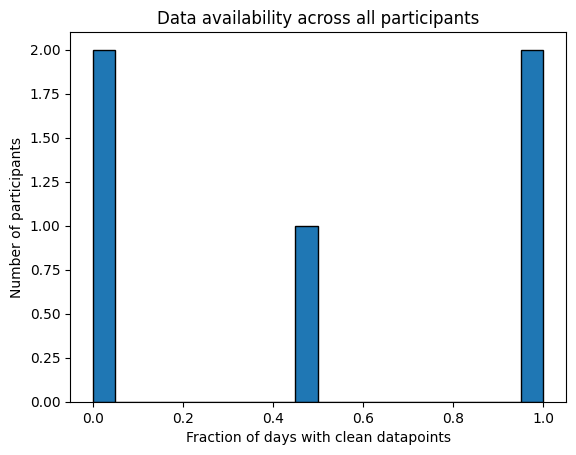

In [9]:

plt.hist(all_participants, bins=20, edgecolor="black")
# Add labels and title
plt.xlabel("Fraction of days with clean datapoints")
plt.ylabel("Number of participants")
plt.title("Data availability across all participants")
plt.show()